<a href="https://colab.research.google.com/github/AnkitKumar017/AI-ML_PROJECTS/blob/main/Ravdess_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/ML_Project/Speaker_Recog/ravdness"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

all_actors = sorted(os.listdir(DATA_ROOT))
all_actors


['Actor_01',
 'Actor_02',
 'Actor_03',
 'Actor_04',
 'Actor_05',
 'Actor_06',
 'Actor_07',
 'Actor_08',
 'Actor_09',
 'Actor_10',
 'Actor_11',
 'Actor_12',
 'Actor_13',
 'Actor_14',
 'Actor_15',
 'Actor_16',
 'Actor_17',
 'Actor_18',
 'Actor_19',
 'Actor_20',
 'Actor_21',
 'Actor_22',
 'Actor_23',
 'Actor_24']

In [ ]:
selected_actors = all_actors[:8]
selected_actors


['Actor_01',
 'Actor_02',
 'Actor_03',
 'Actor_04',
 'Actor_05',
 'Actor_06',
 'Actor_07',
 'Actor_08']

In [ ]:


SAMPLE_RATE = 16000
DURATION = 3.0

def load_audio(file_path, sr=SAMPLE_RATE, duration=DURATION):
    y, sr = librosa.load(file_path, sr=sr, mono=True, duration=duration)
    y = librosa.util.normalize(y)
    return y, sr

def extract_mfcc(y, sr, n_mfcc=20):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc, axis=1)
    feature_vector = np.concatenate([mfcc_mean, mfcc_std])
    return feature_vector


In [ ]:
X = []
y = []

for actor in selected_actors:
    actor_path = os.path.join(DATA_ROOT, actor)
    for fname in os.listdir(actor_path):
        if not fname.lower().endswith(".wav"):
            continue

        fpath = os.path.join(actor_path, fname)
        try:
            audio, sr = load_audio(fpath)
            feats = extract_mfcc(audio, sr)
            X.append(feats)
            y.append(actor)
        except Exception as e:
            print("Error with file:", fpath, e)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Unique speakers:", np.unique(y))


Feature matrix shape: (480, 40)
Labels shape: (480,)
Unique speakers: ['Actor_01' 'Actor_02' 'Actor_03' 'Actor_04' 'Actor_05' 'Actor_06'
 'Actor_07' 'Actor_08']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(X_train.shape, X_test.shape)


(384, 40) (96, 40)


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale')
)

svm_clf.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC(C=10))])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = svm_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
cm


Accuracy: 0.96875

Classification report:

              precision    recall  f1-score   support

    Actor_01       1.00      1.00      1.00        12
    Actor_02       1.00      0.92      0.96        12
    Actor_03       1.00      1.00      1.00        12
    Actor_04       0.91      0.83      0.87        12
    Actor_05       1.00      1.00      1.00        12
    Actor_06       0.86      1.00      0.92        12
    Actor_07       1.00      1.00      1.00        12
    Actor_08       1.00      1.00      1.00        12

    accuracy                           0.97        96
   macro avg       0.97      0.97      0.97        96
weighted avg       0.97      0.97      0.97        96



array([[12,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 11,  0,  1,  0,  0,  0,  0],
       [ 0,  0, 12,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 10,  0,  2,  0,  0],
       [ 0,  0,  0,  0, 12,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 12,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 12,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 12]])

In [ ]:
import joblib

joblib.dump(svm_clf, "svm_mfcc_ravdess.joblib")
joblib.dump(le, "label_encoder_ravdess.joblib")


['label_encoder_ravdess.joblib']

In [ ]:
def predict_speaker(file_path, model, label_encoder):
    y_audio, sr = load_audio(file_path)
    feats = extract_mfcc(y_audio, sr).reshape(1, -1)
    pred_id = model.predict(feats)[0]
    speaker = label_encoder.inverse_transform([pred_id])[0]
    return speaker

# example:
model = joblib.load("svm_mfcc_ravdess.joblib")
label_encoder = joblib.load("label_encoder_ravdess.joblib")

test_file = os.path.join(DATA_ROOT, selected_actors[0],
                         os.listdir(os.path.join(DATA_ROOT, selected_actors[0]))[0])
print("Predicted speaker:", predict_speaker(test_file, model, label_encoder))


Predicted speaker: Actor_01


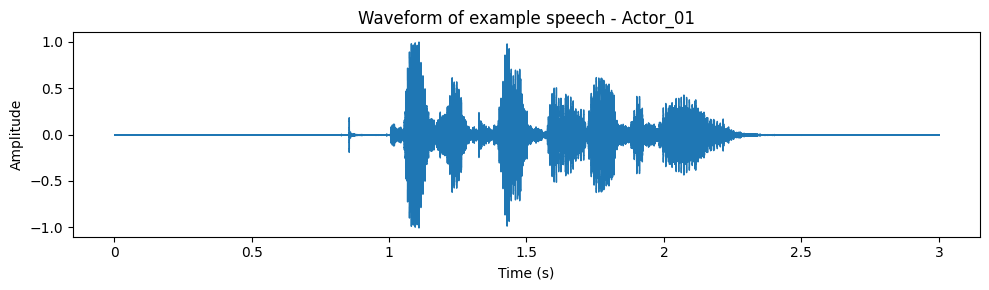

In [ ]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

# Pick a sample file from one actor
example_actor = selected_actors[0]
example_path = os.path.join(DATA_ROOT, example_actor,
                            os.listdir(os.path.join(DATA_ROOT, example_actor))[0])

y_audio, sr = load_audio(example_path)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y_audio, sr=sr)
plt.title(f"Waveform of example speech - {example_actor}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


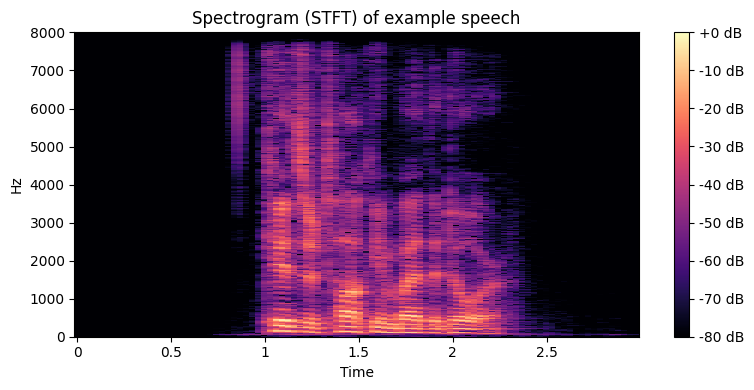

In [ ]:
# Use STFT to get spectrogram
D = librosa.stft(y_audio)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(8, 4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (STFT) of example speech")
plt.tight_layout()
plt.show()


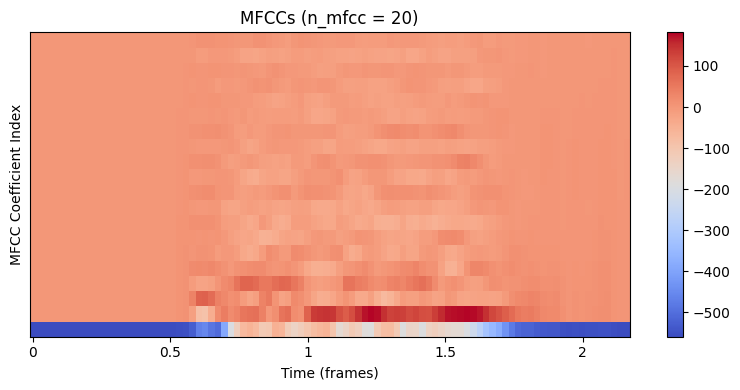

In [ ]:
n_mfcc = 20
mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)

plt.figure(figsize=(8, 4))
librosa.display.specshow(mfcc, x_axis="time")
plt.colorbar()
plt.title(f"MFCCs (n_mfcc = {n_mfcc})")
plt.xlabel("Time (frames)")
plt.ylabel("MFCC Coefficient Index")
plt.tight_layout()
plt.show()


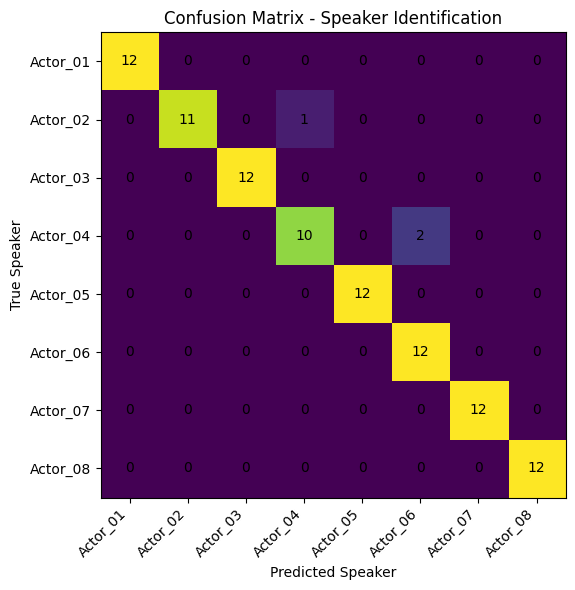

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
classes = le.inverse_transform(np.arange(len(le.classes_)))

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Speaker Identification")
plt.xlabel("Predicted Speaker")
plt.ylabel("True Speaker")
plt.xticks(ticks=np.arange(len(classes)), labels=classes, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(classes)), labels=classes)

# Annotate each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center")

plt.tight_layout()
plt.show()


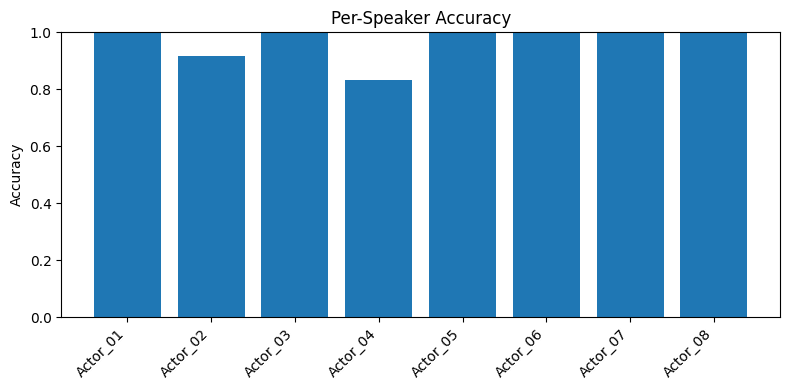

In [ ]:
# Per-class accuracy
num_classes = len(classes)
correct_per_class = np.zeros(num_classes)
total_per_class = np.zeros(num_classes)

for true_label, pred_label in zip(y_test, y_pred):
    total_per_class[true_label] += 1
    if true_label == pred_label:
        correct_per_class[true_label] += 1

acc_per_class = correct_per_class / total_per_class

plt.figure(figsize=(8, 4))
plt.bar(np.arange(num_classes), acc_per_class)
plt.xticks(ticks=np.arange(num_classes), labels=classes, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Per-Speaker Accuracy")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()
